In [21]:
import numpy as np
import matplotlib.pyplot as plt

import helpers
from helpers.helpers import *
from helpers.implementations import *
from preprocessing.rough_cleanup import *





In [2]:
%%time
feature_names, x_train, x_test, y_train, train_ids, test_ids = load_and_cache("./../data/")

loading data took me approximately 1min30s, but loading from cache takes 2 seconds, be patient
loading cached data ...
CPU times: total: 1.45 s
Wall time: 1.46 s


In [3]:
feature_names


array(['_STATE', 'FMONTH', 'IDATE', 'IMONTH', 'IDAY', 'IYEAR', 'DISPCODE',
       'SEQNO', '_PSU', 'CTELENUM', 'PVTRESD1', 'COLGHOUS', 'STATERES',
       'CELLFON3', 'LADULT', 'NUMADULT', 'NUMMEN', 'NUMWOMEN', 'CTELNUM1',
       'CELLFON2', 'CADULT', 'PVTRESD2', 'CCLGHOUS', 'CSTATE', 'LANDLINE',
       'HHADULT', 'GENHLTH', 'PHYSHLTH', 'MENTHLTH', 'POORHLTH',
       'HLTHPLN1', 'PERSDOC2', 'MEDCOST', 'CHECKUP1', 'BPHIGH4', 'BPMEDS',
       'BLOODCHO', 'CHOLCHK', 'TOLDHI2', 'CVDSTRK3', 'ASTHMA3', 'ASTHNOW',
       'CHCSCNCR', 'CHCOCNCR', 'CHCCOPD1', 'HAVARTH3', 'ADDEPEV2',
       'CHCKIDNY', 'DIABETE3', 'DIABAGE2', 'SEX', 'MARITAL', 'EDUCA',
       'RENTHOM1', 'NUMHHOL2', 'NUMPHON2', 'CPDEMO1', 'VETERAN3',
       'EMPLOY1', 'CHILDREN', 'INCOME2', 'INTERNET', 'WEIGHT2', 'HEIGHT3',
       'PREGNANT', 'QLACTLM2', 'USEEQUIP', 'BLIND', 'DECIDE', 'DIFFWALK',
       'DIFFDRES', 'DIFFALON', 'SMOKE100', 'SMOKDAY2', 'STOPSMK2',
       'LASTSMK2', 'USENOW3', 'ALCDAY5', 'AVEDRNK2', 'DRNK3GE5',
    

In [26]:
x_train

array([[5.3000000e+01, 1.1000000e+01, 1.1162015e+07, ...,           nan,
                  nan, 2.0000000e+00],
       [3.3000000e+01, 1.2000000e+01, 1.2152015e+07, ...,           nan,
                  nan,           nan],
       [2.0000000e+01, 1.0000000e+01, 1.0202015e+07, ..., 1.0000000e+00,
        2.0000000e+00, 2.0000000e+00],
       ...,
       [3.9000000e+01, 1.0000000e+01, 1.0202015e+07, ..., 2.0000000e+00,
        2.0000000e+00, 2.0000000e+00],
       [3.3000000e+01, 1.2000000e+01, 1.2302015e+07, ...,           nan,
                  nan, 2.0000000e+00],
       [3.2000000e+01, 9.0000000e+00, 9.1220150e+06, ...,           nan,
                  nan, 2.0000000e+00]], shape=(328135, 321))

In [6]:
train_ids

array([     0,      1,      2, ..., 328132, 328133, 328134],
      shape=(328135,))

In [27]:
np.shape(x_train)

(328135, 321)

In [12]:
nan_counts = audit_missing_values(x_train, feature_names)

<BarContainer object of 101 artists>

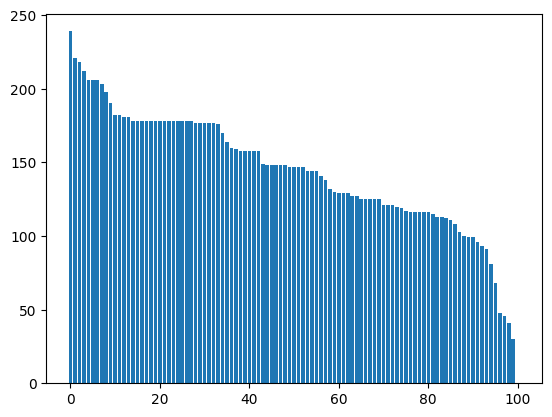

In [25]:
def check_near_empty_features(counts, p):
    return len(counts["col_nan_pcts"][counts["col_nan_pcts"]> p])

distr = [check_near_empty_features(nan_counts, i) for i in range(101)]
plt.bar(np.arange(101), distr)

Sounds like we have a lot of features to throw out